Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Customers: (99441, 5)
Products: (32951, 9)
Category Translation: (71, 2)
Merged Dataset Shape: (118434, 27)
Dataset after cleaning and feature engineering: (118434, 35)
Total Revenue: 16566687.31
Total Orders: 99441
Total Customers: 96096
Average Order Value: 166.6

Top 10 States by Revenue:
customer_state
SP    6201661.39
RJ    2236978.11
MG    1920938.14
RS     929350.22
PR     828526.16
BA     647949.82
SC     630431.81
DF     365186.90
GO     365071.75
ES     335290.50
Name: revenue, dtype: float64

Top 10 Categories by Revenue:
product_category_name_english
health_beauty            1486023.75
watches_gifts            1357478.82
bed_bath_table           1310284.13
sports_leisure           1198524.35
computers_accessories    1095456.98
furniture_decor           946593.12
housewares                820851.24
cool_stuff                750150.02
auto                      712442.08
garden_tools              623851.98
Name: reven

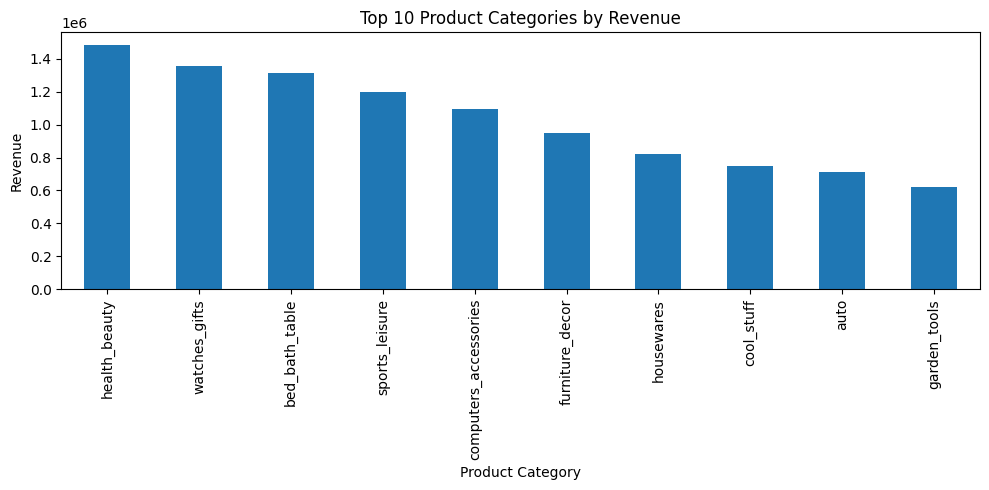

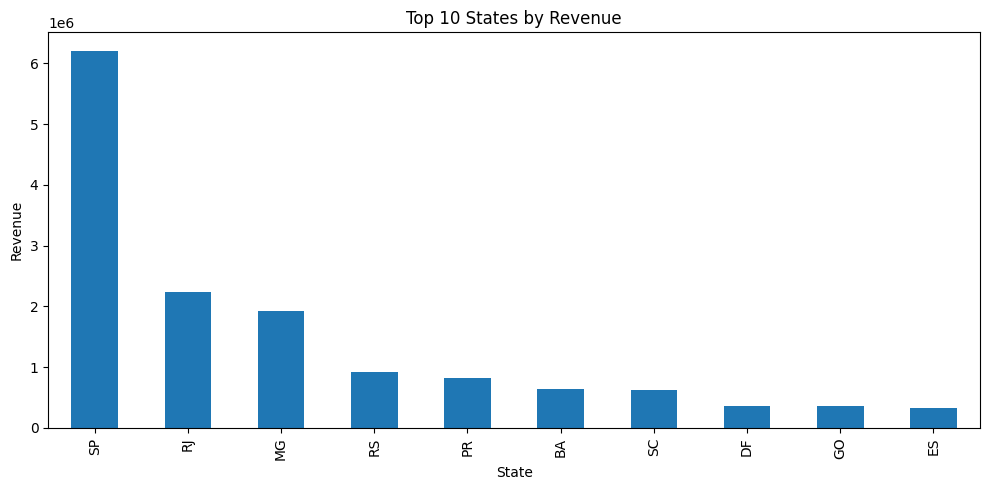

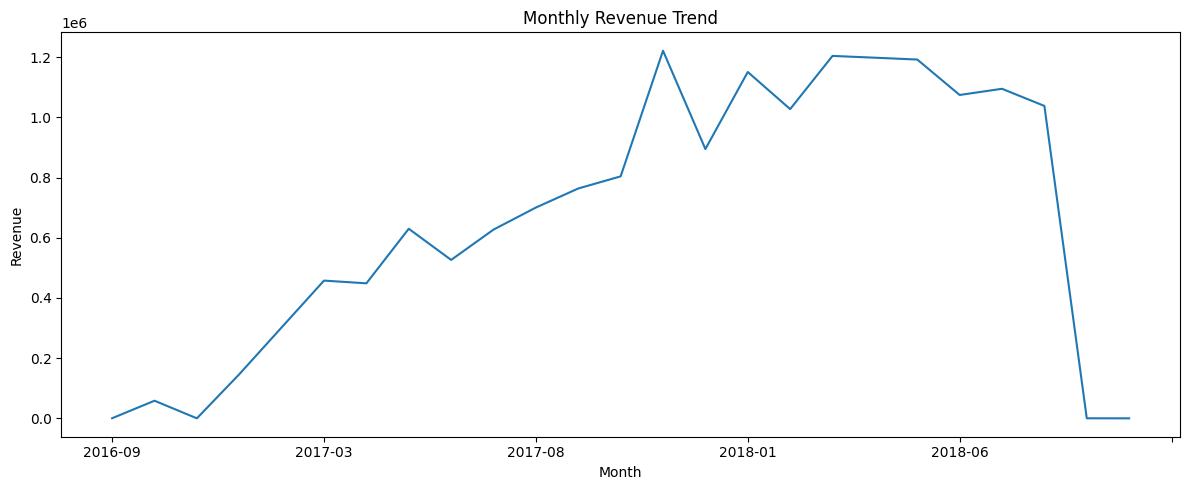

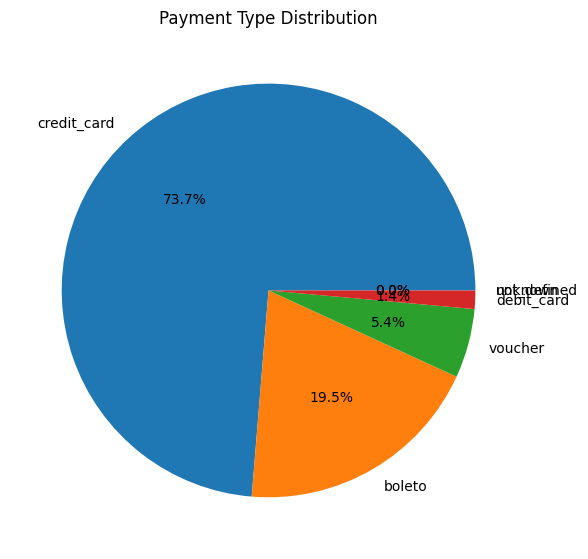

Final dataset exported successfully as sales_analytics_final.csv


In [1]:
# Sales Analytics Dashboard & ETL Pipeline
# Dataset: Olist Brazilian E-Commerce Dataset

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load Datasets
# =========================

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Category Translation:", category_translation.shape)

# =========================
# 2. Merge Product Category Translation
# =========================

products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# =========================
# 3. Create Final Sales Dataset
# =========================

sales_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

sales_df = sales_df.merge(
    items,
    on="order_id",
    how="left"
)

sales_df = sales_df.merge(
    payments,
    on="order_id",
    how="left"
)

sales_df = sales_df.merge(
    products_en[
        [
            "product_id",
            "product_category_name_english",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

print("Merged Dataset Shape:", sales_df.shape)

# =========================
# 4. Data Cleaning
# =========================

sales_df.drop_duplicates(inplace=True)

sales_df["order_purchase_timestamp"] = pd.to_datetime(
    sales_df["order_purchase_timestamp"],
    errors="coerce"
)

sales_df["order_approved_at"] = pd.to_datetime(
    sales_df["order_approved_at"],
    errors="coerce"
)

sales_df["order_delivered_customer_date"] = pd.to_datetime(
    sales_df["order_delivered_customer_date"],
    errors="coerce"
)

sales_df["order_estimated_delivery_date"] = pd.to_datetime(
    sales_df["order_estimated_delivery_date"],
    errors="coerce"
)

sales_df["price"] = sales_df["price"].fillna(0)
sales_df["freight_value"] = sales_df["freight_value"].fillna(0)
sales_df["payment_value"] = sales_df["payment_value"].fillna(0)

sales_df["product_category_name_english"] = sales_df[
    "product_category_name_english"
].fillna("unknown")

sales_df["payment_type"] = sales_df["payment_type"].fillna("unknown")

# =========================
# 5. Feature Engineering
# =========================

sales_df["revenue"] = sales_df["price"] + sales_df["freight_value"]

sales_df["year"] = sales_df["order_purchase_timestamp"].dt.year
sales_df["month"] = sales_df["order_purchase_timestamp"].dt.month
sales_df["month_name"] = sales_df["order_purchase_timestamp"].dt.month_name()
sales_df["year_month"] = sales_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

sales_df["shipping_percentage"] = (
    sales_df["freight_value"] / sales_df["revenue"].replace(0, pd.NA)
) * 100

sales_df["shipping_percentage"] = sales_df["shipping_percentage"].round(2)

sales_df["delivery_days"] = (
    sales_df["order_delivered_customer_date"]
    - sales_df["order_purchase_timestamp"]
).dt.days

sales_df["estimated_delivery_days"] = (
    sales_df["order_estimated_delivery_date"]
    - sales_df["order_purchase_timestamp"]
).dt.days

print("Dataset after cleaning and feature engineering:", sales_df.shape)

# =========================
# 6. KPI Summary
# =========================

total_revenue = sales_df["revenue"].sum()
total_orders = sales_df["order_id"].nunique()
total_customers = sales_df["customer_unique_id"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

# =========================
# 7. Business Analysis
# =========================

print("\nTop 10 States by Revenue:")
print(
    sales_df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Categories by Revenue:")
print(
    sales_df.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nPayment Type Distribution:")
print(
    sales_df["payment_type"]
    .value_counts()
)

# =========================
# 8. EDA Charts
# =========================

top_categories = (
    sales_df.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_categories.plot(kind="bar")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

top_states = (
    sales_df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

monthly_revenue = (
    sales_df.groupby("year_month")["revenue"]
    .sum()
)

plt.figure(figsize=(12, 5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

payment_distribution = sales_df["payment_type"].value_counts()

plt.figure(figsize=(6, 6))
payment_distribution.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Type Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# =========================
# 9. Export Final Dataset
# =========================

sales_df.to_csv("sales_analytics_final.csv", index=False)

print("Final dataset exported successfully as sales_analytics_final.csv")